In [1]:
import pickle
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

PRIMARY_PATH = Path("../../data/03_primary/")
FEATURE_PATH = Path("../../data/04_feature/")
MODEL_INPUT_PATH = Path("../../data/05_model_input/")
MODEL_PATH = Path("../../data/06_models/")
OUTPUT_PATH = Path("../../data/07_model_output/")
REPORT_PATH = Path("../../data/08_reporting/")

for p in [MODEL_INPUT_PATH, MODEL_PATH, OUTPUT_PATH, REPORT_PATH]:
    p.mkdir(parents=True, exist_ok=True)

## 1. Cargar datos y definir split temporal

In [2]:
ventas = pd.read_parquet(PRIMARY_PATH / "ventas_limpias.parquet")
cancelaciones = pd.read_parquet(PRIMARY_PATH / "cancelaciones.parquet")
productos = pd.read_parquet(FEATURE_PATH / "productos_enriquecidos_regex.parquet")

CUTOFF = pd.Timestamp("2011-09-01")

# Split temporal
ventas_obs = ventas[ventas["InvoiceDate"] < CUTOFF].copy()
ventas_pred = ventas[ventas["InvoiceDate"] >= CUTOFF].copy()
cancel_obs = cancelaciones[cancelaciones["InvoiceDate"] < CUTOFF].copy()

# Clientes en cada periodo
cust_obs = set(ventas_obs["CustomerID"].unique())
cust_pred = set(ventas_pred["CustomerID"].unique())

print(f"Periodo de observacion: {ventas_obs.InvoiceDate.min().date()} a {ventas_obs.InvoiceDate.max().date()}")
print(f"Periodo de prediccion:  {ventas_pred.InvoiceDate.min().date()} a {ventas_pred.InvoiceDate.max().date()}")
print(f"\nClientes en observacion: {len(cust_obs):,}")
print(f"Clientes en prediccion: {len(cust_pred):,}")
print(f"Clientes en ambos:      {len(cust_obs & cust_pred):,}")

Periodo de observacion: 2010-12-01 a 2011-08-31
Periodo de prediccion:  2011-09-01 a 2011-12-09

Clientes en observacion: 3,317
Clientes en prediccion: 2,973
Clientes en ambos:      1,952


In [3]:
# Definir target: churn = 1 si el cliente NO compro en el periodo de prediccion
churn_df = pd.DataFrame({"CustomerID": list(cust_obs)})
churn_df["Churn"] = churn_df["CustomerID"].apply(lambda x: 0 if x in cust_pred else 1)

print(f"Clientes en scope: {len(churn_df):,}")
print(f"\nDistribucion del target:")
print(churn_df["Churn"].value_counts())
print(f"\nChurn rate: {churn_df['Churn'].mean()*100:.1f}%")

Clientes en scope: 3,317

Distribucion del target:
Churn
0    1952
1    1365
Name: count, dtype: int64

Churn rate: 41.2%


## 2. Feature engineering (solo con datos del periodo de observacion)

Se recalculan todas las features usando **unicamente** datos anteriores al cutoff (2011-09-01)
para evitar data leakage. Esto es critico: usar datos del periodo de prediccion para construir
features seria trampa.

**Features RFM recalculados (4):**
- `Recency`: dias desde ultima compra hasta 2011-08-31
- `Frequency`: cantidad de facturas unicas
- `Monetary`: revenue neto total (bruto - cancelaciones)
- `Cancel_rate`: (revenue cancelado / revenue bruto) * 100

**Features de producto (5):**
- `pct_with_color`, `color_diversity`, `is_color_specialist`
- `pct_with_material`, `pct_purchases_sets`

**Features adicionales (4):**
- `avg_days_between_purchases`: regularidad de compra
- `months_active`: meses distintos con al menos una compra
- `n_products_unique`: diversidad de productos
- `avg_order_value`: ticket promedio por factura

In [4]:
REF_DATE = pd.Timestamp("2011-08-31")

# --- RFM sobre periodo de observacion ---
rfm_obs = (
    ventas_obs.groupby("CustomerID")
    .agg(
        last_purchase=("InvoiceDate", "max"),
        Frequency=("InvoiceNo", "nunique"),
        Revenue_bruto=("Revenue", "sum"),
    )
)
rfm_obs["Recency"] = (REF_DATE - rfm_obs["last_purchase"]).dt.days

# Netear cancelaciones del periodo de observacion
cancel_revenue = (
    cancel_obs.assign(Revenue=lambda df: df["Quantity"].abs() * df["UnitPrice"])
    .groupby("CustomerID")["Revenue"]
    .sum()
    .rename("Revenue_cancelado")
)
rfm_obs = rfm_obs.join(cancel_revenue, how="left")
rfm_obs["Revenue_cancelado"] = rfm_obs["Revenue_cancelado"].fillna(0)
rfm_obs["Monetary"] = (rfm_obs["Revenue_bruto"] - rfm_obs["Revenue_cancelado"]).clip(lower=0)
rfm_obs["Cancel_rate"] = np.where(
    rfm_obs["Revenue_bruto"] > 0,
    rfm_obs["Revenue_cancelado"] / rfm_obs["Revenue_bruto"] * 100,
    0,
)

rfm_obs = rfm_obs[["Recency", "Frequency", "Monetary", "Cancel_rate"]].reset_index()
print(f"RFM calculado para {len(rfm_obs):,} clientes")
rfm_obs.describe().round(2)

RFM calculado para 3,317 clientes


,CustomerID,Recency,Frequency,Monetary,Cancel_rate
count,3317.00,3317.00,3317.00,3317.00,3317.00
mean,15284.20,91.14,3.44,1487.13,4.35
std,1724.18,76.69,5.59,5569.94,99.62
min,12346.00,-1.00,1.00,0.00,0.00
25%,13799.00,26.00,1.00,252.29,0.00
50%,15245.00,71.00,2.00,541.51,0.00
75%,16770.00,145.00,4.00,1327.26,1.17
max,18287.00,272.00,127.00,175638.94,5705.07


In [5]:
# --- Features adicionales ---

# avg_days_between_purchases: regularidad
invoice_dates = (
    ventas_obs.groupby("CustomerID")["InvoiceDate"]
    .apply(lambda x: x.sort_values().diff().dt.days.mean())
    .rename("avg_days_between_purchases")
)

# months_active: meses distintos con compras
months_active = (
    ventas_obs.assign(month=ventas_obs["InvoiceDate"].dt.to_period("M"))
    .groupby("CustomerID")["month"]
    .nunique()
    .rename("months_active")
)

# n_products_unique: diversidad de productos
n_products = (
    ventas_obs.groupby("CustomerID")["StockCode"]
    .nunique()
    .rename("n_products_unique")
)

# avg_order_value: ticket promedio por factura
aov = (
    ventas_obs.groupby(["CustomerID", "InvoiceNo"])["Revenue"]
    .sum()
    .reset_index()
    .groupby("CustomerID")["Revenue"]
    .mean()
    .rename("avg_order_value")
)

extra_features = pd.concat([invoice_dates, months_active, n_products, aov], axis=1).reset_index()
# Clientes con 1 sola compra tienen NaN en avg_days_between_purchases
extra_features["avg_days_between_purchases"] = extra_features["avg_days_between_purchases"].fillna(-1)

print(f"Features adicionales para {len(extra_features):,} clientes")
extra_features.describe().round(2)

Features adicionales para 3,317 clientes


,CustomerID,avg_days_between_purchases,months_active,n_products_unique,avg_order_value
count,3317.00,3317.00,3317.00,3317.00,3317.00
mean,15284.20,2.42,2.46,49.09,400.58
std,1724.18,9.24,1.95,66.19,1435.76
min,12346.00,-1.00,1.00,1.00,2.90
25%,13799.00,0.00,1.00,13.00,169.37
50%,15245.00,0.64,2.00,29.00,284.55
75%,16770.00,2.29,3.00,62.00,415.21
max,18287.00,245.00,9.00,1190.00,77183.60


In [6]:
# --- Atributos de producto (recalculados sobre periodo de observacion) ---

# Join ventas con productos enriquecidos
ventas_prod = ventas_obs.merge(
    productos[["Description", "has_color", "has_material", "is_set", "n_attributes"]],
    on="Description",
    how="left",
)

# Calcular color_diversity usando la lista de colores por producto
COLOR_COLS = [c for c in productos.columns if c.startswith("has_") and c.replace("has_", "").upper()
              in ["RED","PINK","WHITE","BLUE","IVORY","CREAM","GREEN","BLACK","SILVER",
                  "YELLOW","PURPLE","GREY","ORANGE","GOLD","BROWN"]]

prod_colors = productos[["Description"] + COLOR_COLS].copy()
ventas_colors = ventas_obs[["CustomerID", "Description"]].merge(prod_colors, on="Description", how="left")

# Agregar por cliente
prod_feat = (
    ventas_prod.groupby("CustomerID")
    .agg(
        total_items=("Description", "count"),
        items_with_color=("has_color", "sum"),
        items_with_material=("has_material", "sum"),
        items_is_set=("is_set", "sum"),
    )
)
prod_feat["pct_with_color"] = prod_feat["items_with_color"] / prod_feat["total_items"] * 100
prod_feat["pct_with_material"] = prod_feat["items_with_material"] / prod_feat["total_items"] * 100
prod_feat["pct_purchases_sets"] = prod_feat["items_is_set"] / prod_feat["total_items"] * 100

# Color diversity (entropy-based) por cliente
color_sums = ventas_colors.groupby("CustomerID")[COLOR_COLS].sum()
color_totals = color_sums.sum(axis=1)
color_probs = color_sums.div(color_totals, axis=0).replace(0, np.nan)
prod_feat["color_diversity"] = -(color_probs * np.log2(color_probs)).sum(axis=1).fillna(0)

# is_color_specialist: >80% de compras con color son del mismo color
max_color_pct = color_sums.div(color_totals, axis=0).max(axis=1)
prod_feat["is_color_specialist"] = (max_color_pct > 0.8).astype(int)

prod_feat = prod_feat[["pct_with_color", "color_diversity", "is_color_specialist",
                        "pct_with_material", "pct_purchases_sets"]].reset_index()

print(f"Atributos de producto para {len(prod_feat):,} clientes")
prod_feat.describe().round(2)

Atributos de producto para 3,317 clientes


,CustomerID,pct_with_color,color_diversity,is_color_specialist,pct_with_material,pct_purchases_sets
count,3317.00,3317.00,3317.00,3317.00,3317.00,3317.00
mean,15284.20,30.65,1.77,0.09,19.28,7.27
std,1724.18,17.31,0.93,0.28,16.04,9.44
min,12346.00,0.00,-0.00,0.00,0.00,0.00
25%,13799.00,20.00,1.15,0.00,8.96,0.00
50%,15245.00,29.41,1.99,0.00,16.67,5.26
75%,16770.00,39.13,2.49,0.00,25.93,10.45
max,18287.00,100.00,3.50,1.00,100.00,100.00


In [7]:
# --- Ensamblar dataset final ---
df = churn_df.merge(rfm_obs, on="CustomerID").merge(extra_features, on="CustomerID").merge(prod_feat, on="CustomerID")

FEATURE_NAMES = [
    # RFM
    "Recency", "Frequency", "Monetary", "Cancel_rate",
    # Producto
    "pct_with_color", "color_diversity", "is_color_specialist",
    "pct_with_material", "pct_purchases_sets",
    # Adicionales
    "avg_days_between_purchases", "months_active", "n_products_unique", "avg_order_value",
]

print(f"Dataset final: {df.shape[0]:,} clientes x {len(FEATURE_NAMES)} features")
print(f"Churn rate: {df['Churn'].mean()*100:.1f}%")
print(f"\nFeatures: {FEATURE_NAMES}")
print(f"\nNulls por feature:")
print(df[FEATURE_NAMES].isnull().sum())

# Guardar dataset de modelado
df.to_parquet(MODEL_INPUT_PATH / "churn_dataset.parquet", index=False)

Dataset final: 3,317 clientes x 13 features
Churn rate: 41.2%

Features: ['Recency', 'Frequency', 'Monetary', 'Cancel_rate', 'pct_with_color', 'color_diversity', 'is_color_specialist', 'pct_with_material', 'pct_purchases_sets', 'avg_days_between_purchases', 'months_active', 'n_products_unique', 'avg_order_value']

Nulls por feature:
Recency                       0
Frequency                     0
Monetary                      0
Cancel_rate                   0
pct_with_color                0
color_diversity               0
is_color_specialist           0
pct_with_material             0
pct_purchases_sets            0
avg_days_between_purchases    0
months_active                 0
n_products_unique             0
avg_order_value               0
dtype: int64


## 3. Analisis exploratorio del dataset de churn

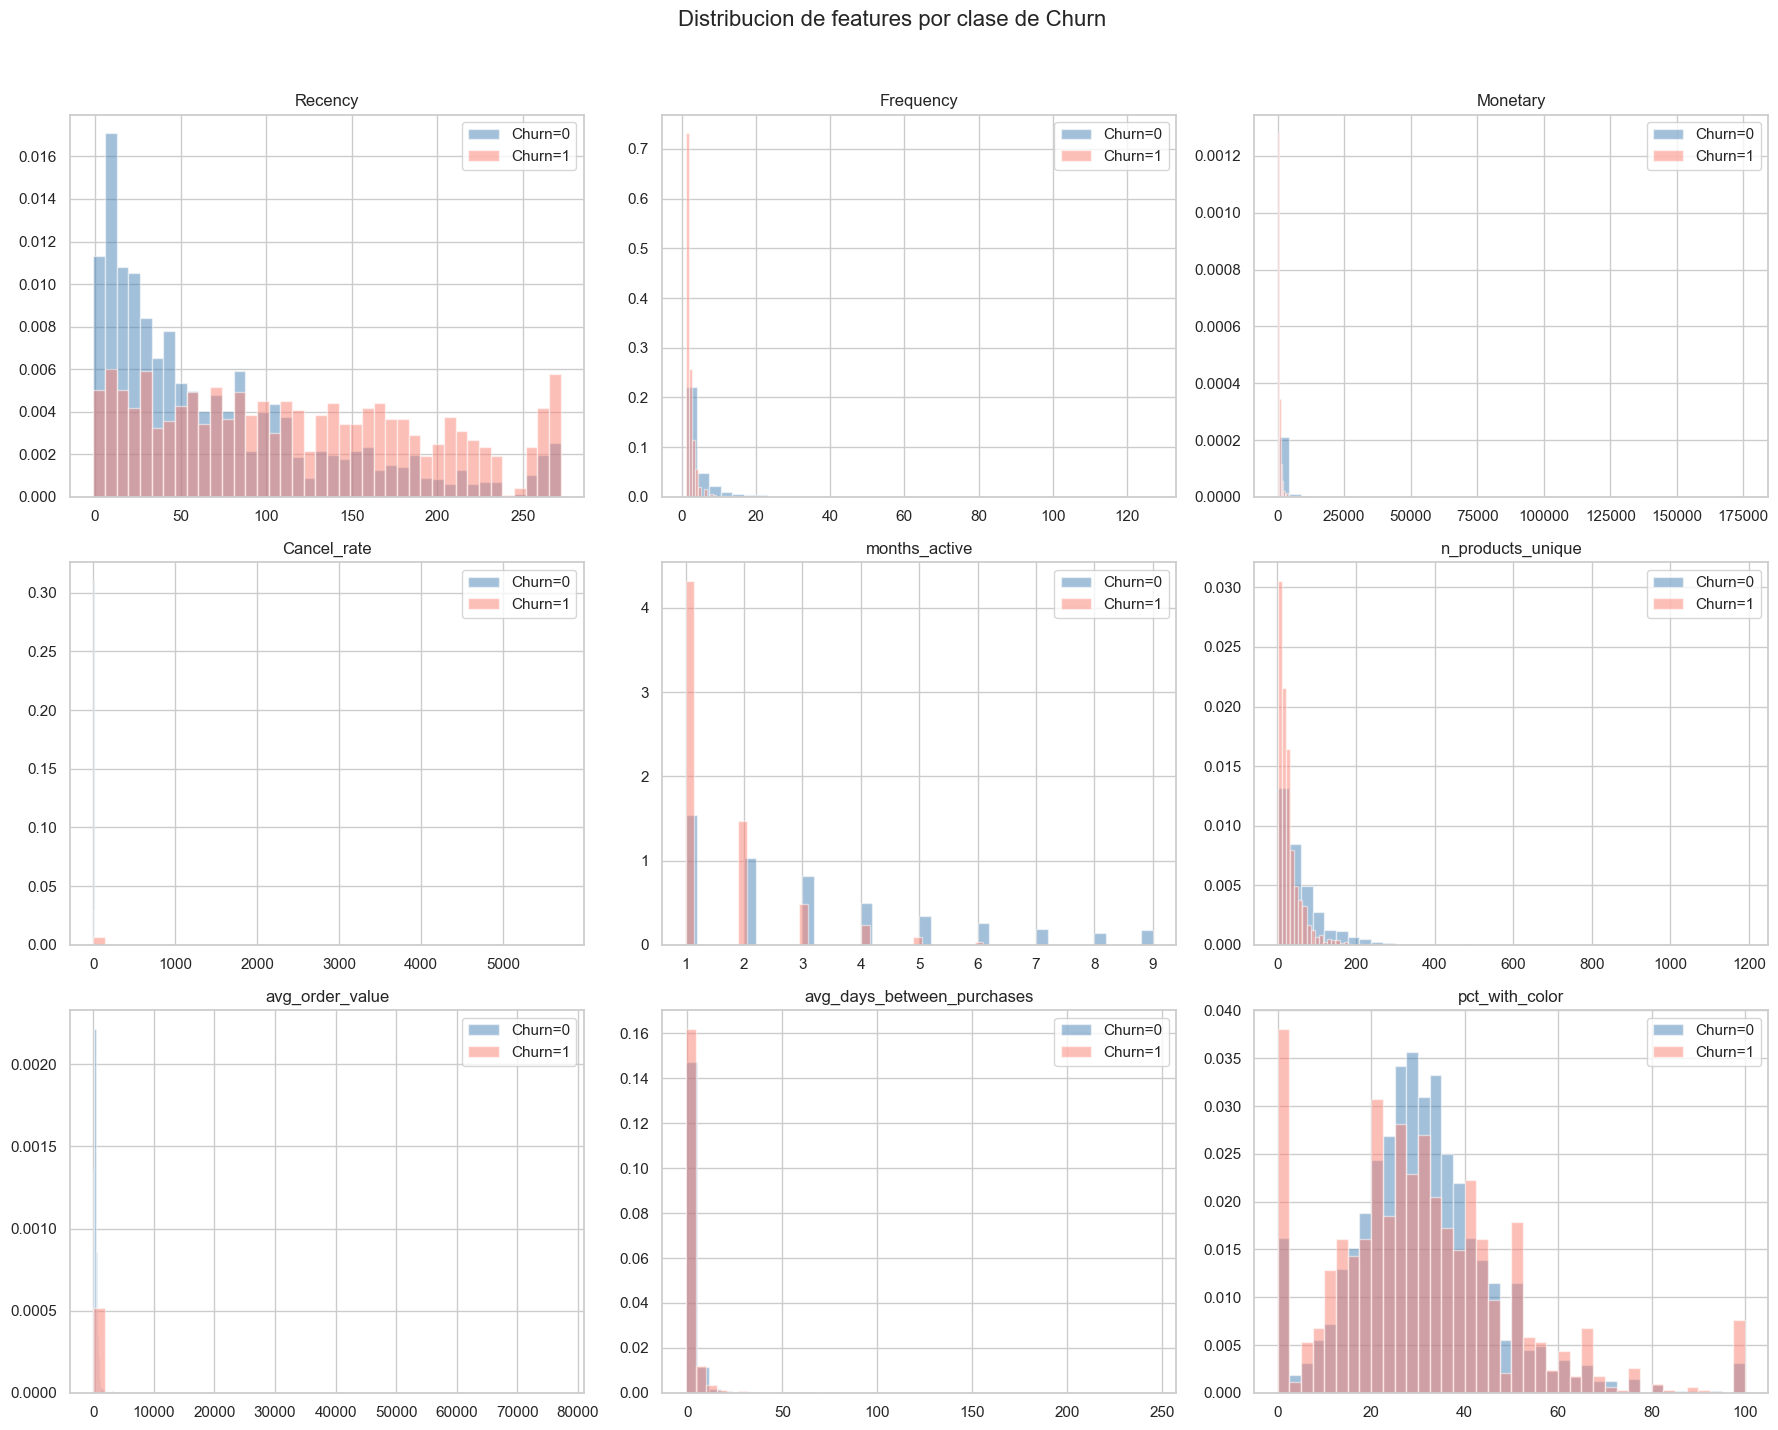

In [8]:
# Distribucion de features por clase
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

plot_features = ["Recency", "Frequency", "Monetary", "Cancel_rate",
                 "months_active", "n_products_unique", "avg_order_value",
                 "avg_days_between_purchases", "pct_with_color"]

for i, feat in enumerate(plot_features):
    for label, color in [(0, "steelblue"), (1, "salmon")]:
        subset = df[df["Churn"] == label][feat]
        axes[i].hist(subset, bins=40, alpha=0.5, label=f"Churn={label}", color=color, density=True)
    axes[i].set_title(feat)
    axes[i].legend()

plt.suptitle("Distribucion de features por clase de Churn", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(REPORT_PATH / "churn_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# Promedios por clase
comparison = df.groupby("Churn")[FEATURE_NAMES].mean().round(2).T
comparison.columns = ["Retained (0)", "Churned (1)"]
comparison["Diff %"] = ((comparison["Churned (1)"] - comparison["Retained (0)"]) / comparison["Retained (0)"].replace(0, np.nan) * 100).round(1)
print("Promedios por clase:")
print(comparison.to_string())

Promedios por clase:
                            Retained (0)  Churned (1)  Diff %
Recency                            71.37       119.42    67.3
Frequency                           4.59         1.80   -60.8
Monetary                         2118.99       583.56   -72.5
Cancel_rate                         2.33         7.24   210.7
pct_with_color                     30.91        30.28    -2.0
color_diversity                     1.95         1.50   -23.1
is_color_specialist                 0.07         0.12    71.4
pct_with_material                  18.85        19.89     5.5
pct_purchases_sets                  7.35         7.17    -2.4
avg_days_between_purchases          2.58         2.20   -14.7
months_active                       3.08         1.57   -49.0
n_products_unique                  63.45        28.55   -55.0
avg_order_value                   396.95       405.76     2.2


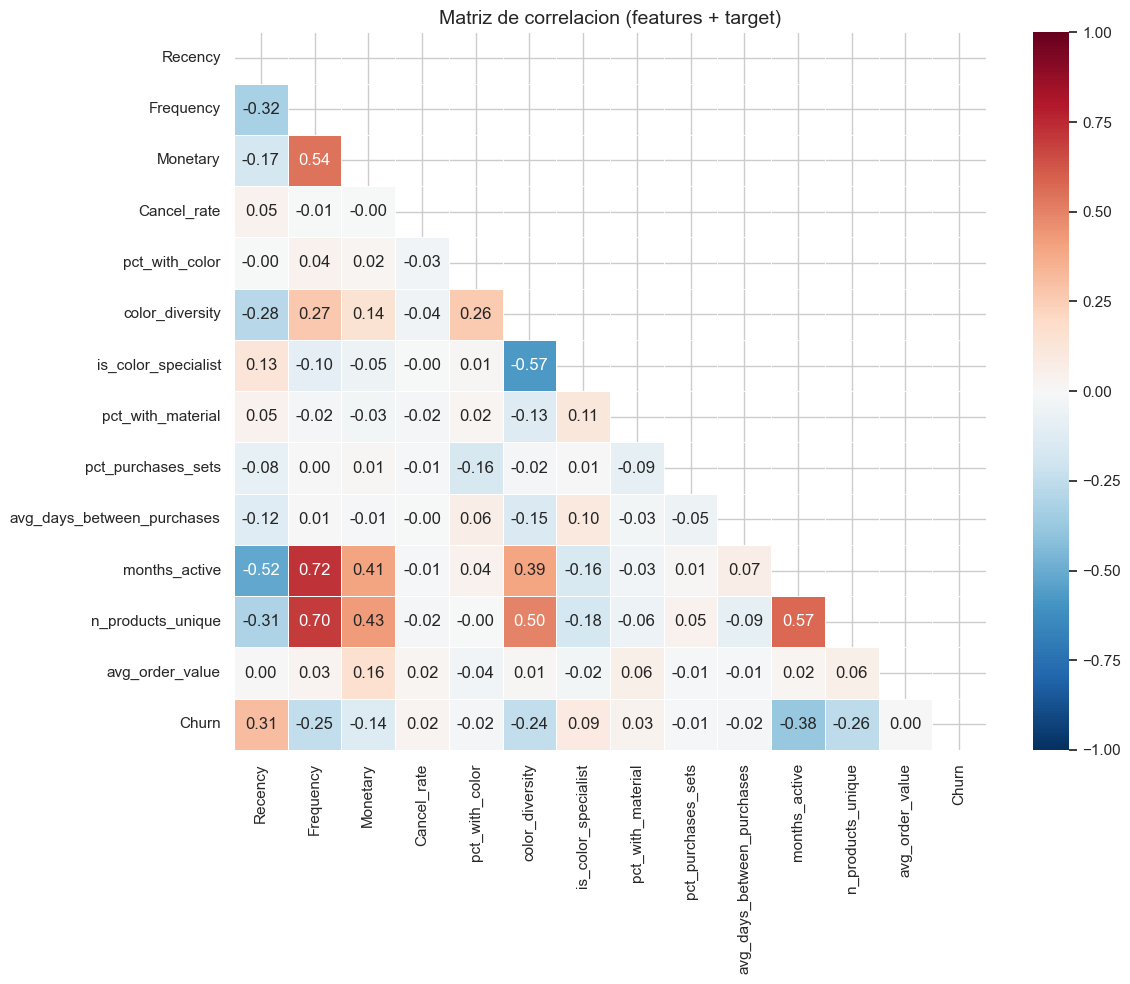

In [10]:
# Correlacion entre features
fig, ax = plt.subplots(figsize=(12, 10))
corr = df[FEATURE_NAMES + ["Churn"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title("Matriz de correlacion (features + target)", fontsize=14)
plt.tight_layout()
plt.savefig(REPORT_PATH / "churn_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Split train/test y estandarizacion

In [11]:
X = df[FEATURE_NAMES].values
y = df["Churn"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Estandarizar (fit solo en train)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]:,} ({y_train.mean()*100:.1f}% churn)")
print(f"Test:  {X_test.shape[0]:,} ({y_test.mean()*100:.1f}% churn)")

Train: 2,653 (41.2% churn)
Test:  664 (41.1% churn)


## 5. Entrenamiento de modelos

Comparamos dos algoritmos:
1. **Random Forest** - baseline robusto, interpretable via feature importance
2. **Gradient Boosting** - alternativa a LightGBM (no instalado), generalmente mejor performance

Para cada uno, usamos GridSearchCV con 5-fold stratificado optimizando F1-score.

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Random Forest ---
rf_params = {
    "n_estimators": [200],
    "max_depth": [10, 15, None],
    "min_samples_leaf": [5, 10],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    refit=True,
)
rf_grid.fit(X_train_scaled, y_train)

print("=== Random Forest ===")
print(f"Mejores hiperparametros: {rf_grid.best_params_}")
print(f"Mejor F1 (CV): {rf_grid.best_score_:.4f}")

ERROR:root:code for hash blake2b was not found.
Traceback (most recent call last):
  File "/Users/gruizcamauer/.pyenv/versions/3.11.9/lib/python3.11/hashlib.py", line 307, in <module>
    globals()[__func_name] = __get_hash(__func_name)
                             ^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/gruizcamauer/.pyenv/versions/3.11.9/lib/python3.11/hashlib.py", line 129, in __get_openssl_constructor
    return __get_builtin_constructor(name)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/gruizcamauer/.pyenv/versions/3.11.9/lib/python3.11/hashlib.py", line 123, in __get_builtin_constructor
    raise ValueError('unsupported hash type ' + name)
ValueError: unsupported hash type blake2b
ERROR:root:code for hash blake2s was not found.
Traceback (most recent call last):
  File "/Users/gruizcamauer/.pyenv/versions/3.11.9/lib/python3.11/hashlib.py", line 307, in <module>
    globals()[__func_name] = __get_hash(__func_name)
                             ^^^^^^^^^^^^^^^^^^^^^^^
  

=== Random Forest ===
Mejores hiperparametros: {'max_depth': 10, 'min_samples_leaf': 10, 'n_estimators': 200}
Mejor F1 (CV): 0.6160


In [13]:
# --- Gradient Boosting ---
gb_params = {
    "n_estimators": [200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    refit=True,
)
gb_grid.fit(X_train_scaled, y_train)

print("=== Gradient Boosting ===")
print(f"Mejores hiperparametros: {gb_grid.best_params_}")
print(f"Mejor F1 (CV): {gb_grid.best_score_:.4f}")

=== Gradient Boosting ===
Mejores hiperparametros: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}
Mejor F1 (CV): 0.5995


In [14]:
# --- Comparacion y seleccion ---
print("=== Comparacion de modelos (CV F1) ===")
print(f"Random Forest:     {rf_grid.best_score_:.4f}")
print(f"Gradient Boosting: {gb_grid.best_score_:.4f}")

if gb_grid.best_score_ >= rf_grid.best_score_:
    best_model = gb_grid.best_estimator_
    best_name = "Gradient Boosting"
else:
    best_model = rf_grid.best_estimator_
    best_name = "Random Forest"

print(f"\nModelo seleccionado: {best_name}")

=== Comparacion de modelos (CV F1) ===
Random Forest:     0.6160
Gradient Boosting: 0.5995

Modelo seleccionado: Random Forest


## 6. Evaluacion en test set

In [15]:
# Evaluacion de ambos modelos en test
models = {
    "Random Forest": rf_grid.best_estimator_,
    "Gradient Boosting": gb_grid.best_estimator_,
}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=["Retained", "Churned"]))
    print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}")


Random Forest
              precision    recall  f1-score   support

    Retained       0.74      0.71      0.73       391
     Churned       0.61      0.64      0.62       273

    accuracy                           0.68       664
   macro avg       0.67      0.68      0.67       664
weighted avg       0.68      0.68      0.68       664

AUC-ROC: 0.7444

Gradient Boosting
              precision    recall  f1-score   support

    Retained       0.72      0.70      0.71       391
     Churned       0.59      0.62      0.60       273

    accuracy                           0.66       664
   macro avg       0.65      0.66      0.66       664
weighted avg       0.67      0.66      0.67       664

AUC-ROC: 0.7333


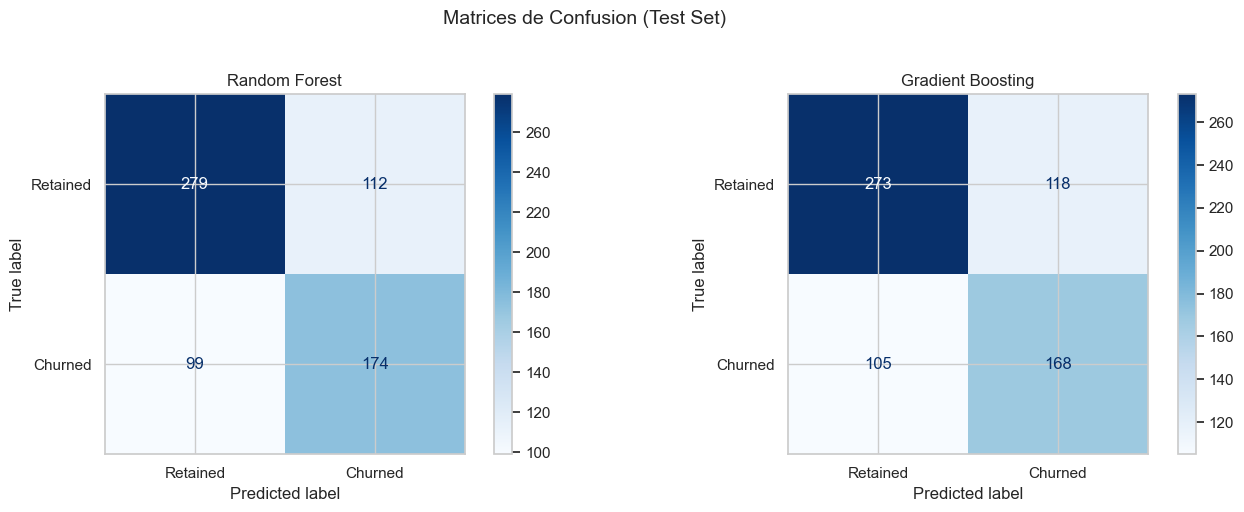

In [16]:
# Matrices de confusion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_scaled)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=["Retained", "Churned"],
        cmap="Blues", ax=axes[i]
    )
    axes[i].set_title(f"{name}")

plt.suptitle("Matrices de Confusion (Test Set)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(REPORT_PATH / "churn_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

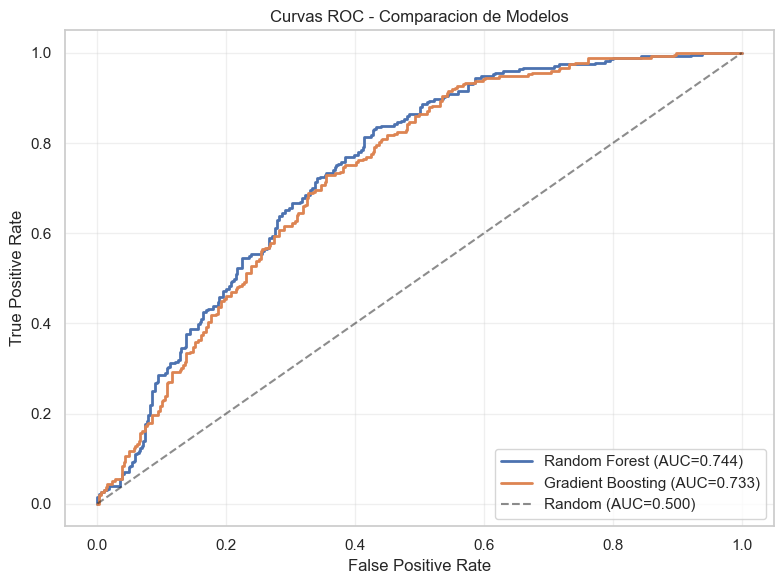

In [17]:
# Curvas ROC
fig, ax = plt.subplots(figsize=(8, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", linewidth=2)

ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random (AUC=0.500)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Curvas ROC - Comparacion de Modelos")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(REPORT_PATH / "churn_roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Interpretacion: Feature Importance

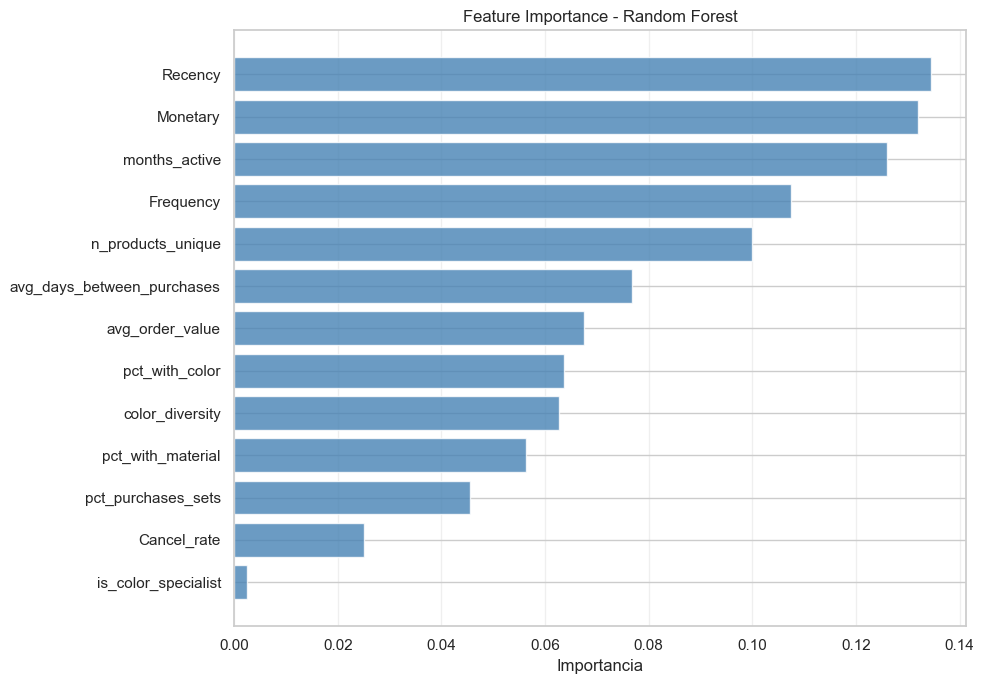


Ranking de features:
  Recency                        0.1345
  Monetary                       0.1320
  months_active                  0.1260
  Frequency                      0.1076
  n_products_unique              0.0999
  avg_days_between_purchases     0.0768
  avg_order_value                0.0675
  pct_with_color                 0.0637
  color_diversity                0.0627
  pct_with_material              0.0563
  pct_purchases_sets             0.0455
  Cancel_rate                    0.0250
  is_color_specialist            0.0024


In [18]:
# Feature importance del mejor modelo
importances = best_model.feature_importances_
feat_imp = pd.DataFrame({
    "Feature": FEATURE_NAMES,
    "Importance": importances,
}).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(feat_imp["Feature"], feat_imp["Importance"], color="steelblue", alpha=0.8)
ax.set_xlabel("Importancia")
ax.set_title(f"Feature Importance - {best_name}")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig(REPORT_PATH / "churn_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nRanking de features:")
for _, row in feat_imp.iloc[::-1].iterrows():
    print(f"  {row['Feature']:30s} {row['Importance']:.4f}")

## 8. Comparacion: modelo con features de producto vs solo RFM

Para cuantificar el aporte del enriquecimiento, comparamos el mejor modelo usando
todas las features vs solo las 4 features RFM tradicionales.

In [19]:
# Modelo solo con RFM (4 features)
RFM_ONLY = ["Recency", "Frequency", "Monetary", "Cancel_rate"]
rfm_idx = [FEATURE_NAMES.index(f) for f in RFM_ONLY]

X_train_rfm = X_train_scaled[:, rfm_idx]
X_test_rfm = X_test_scaled[:, rfm_idx]

# Entrenar el mismo tipo de modelo con los mismos hiperparametros
if best_name == "Gradient Boosting":
    model_rfm = GradientBoostingClassifier(**gb_grid.best_params_, random_state=42)
else:
    model_rfm = RandomForestClassifier(**rf_grid.best_params_, random_state=42, n_jobs=-1)

model_rfm.fit(X_train_rfm, y_train)

# Evaluar ambos
y_pred_full = best_model.predict(X_test_scaled)
y_prob_full = best_model.predict_proba(X_test_scaled)[:, 1]

y_pred_rfm = model_rfm.predict(X_test_rfm)
y_prob_rfm = model_rfm.predict_proba(X_test_rfm)[:, 1]

print("=== Comparacion: RFM solo vs RFM + Producto + Adicionales ===\n")
print(f"{'Metrica':<20} {'RFM solo':>12} {'Completo (13 feat)':>20}")
print("-" * 55)
print(f"{'F1 (Churn)':<20} {f1_score(y_test, y_pred_rfm):>12.4f} {f1_score(y_test, y_pred_full):>20.4f}")
print(f"{'AUC-ROC':<20} {roc_auc_score(y_test, y_prob_rfm):>12.4f} {roc_auc_score(y_test, y_prob_full):>20.4f}")

delta_f1 = f1_score(y_test, y_pred_full) - f1_score(y_test, y_pred_rfm)
delta_auc = roc_auc_score(y_test, y_prob_full) - roc_auc_score(y_test, y_prob_rfm)
print(f"\nDelta F1:  {delta_f1:+.4f}")
print(f"Delta AUC: {delta_auc:+.4f}")

=== Comparacion: RFM solo vs RFM + Producto + Adicionales ===

Metrica                  RFM solo   Completo (13 feat)
-------------------------------------------------------
F1 (Churn)                 0.6275               0.6225
AUC-ROC                    0.7506               0.7444

Delta F1:  -0.0049
Delta AUC: -0.0062


## 9. Analisis de errores

In [20]:
# Analisis de errores: que clientes clasifica mal?
y_pred_final = best_model.predict(X_test_scaled)
y_prob_final = best_model.predict_proba(X_test_scaled)[:, 1]

test_df = df.iloc[len(X_train):].copy()
test_df["y_pred"] = y_pred_final
test_df["y_prob"] = y_prob_final
test_df["correct"] = (test_df["Churn"] == test_df["y_pred"]).astype(int)

# Tipos de error
test_df["error_type"] = "Correct"
test_df.loc[(test_df["Churn"] == 1) & (test_df["y_pred"] == 0), "error_type"] = "FN (missed churn)"
test_df.loc[(test_df["Churn"] == 0) & (test_df["y_pred"] == 1), "error_type"] = "FP (false alarm)"

print("Distribucion de errores:")
print(test_df["error_type"].value_counts())

# Perfil de cada tipo de error
print("\n\nPerfil promedio por tipo de prediccion:")
error_profile = test_df.groupby("error_type")[FEATURE_NAMES].mean().round(2).T
print(error_profile.to_string())

Distribucion de errores:
error_type
Correct              327
FN (missed churn)    171
FP (false alarm)     166
Name: count, dtype: int64


Perfil promedio por tipo de prediccion:
error_type                  Correct  FN (missed churn)  FP (false alarm)
Recency                       88.83             121.90             67.55
Frequency                      3.36               1.80              4.30
Monetary                    1240.21             673.94           1935.42
Cancel_rate                    2.55              36.90              1.89
pct_with_color                30.66              27.67             32.16
color_diversity                1.81               1.39              2.03
is_color_specialist            0.09               0.16              0.04
pct_with_material             18.93              19.45             18.46
pct_purchases_sets             7.61               7.21              7.02
avg_days_between_purchases     2.19               1.16              3.28
months_active     

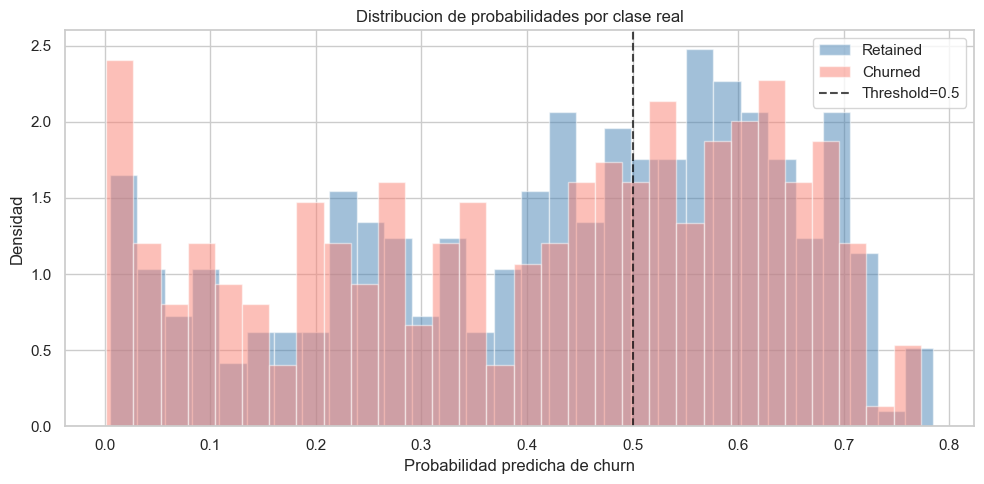

In [21]:
# Distribucion de probabilidades predichas por clase real
fig, ax = plt.subplots(figsize=(10, 5))
for label, color, name in [(0, "steelblue", "Retained"), (1, "salmon", "Churned")]:
    probs = test_df[test_df["Churn"] == label]["y_prob"]
    ax.hist(probs, bins=30, alpha=0.5, color=color, label=name, density=True)
ax.axvline(0.5, color="black", linestyle="--", alpha=0.7, label="Threshold=0.5")
ax.set_xlabel("Probabilidad predicha de churn")
ax.set_ylabel("Densidad")
ax.set_title("Distribucion de probabilidades por clase real")
ax.legend()
plt.tight_layout()
plt.savefig(REPORT_PATH / "churn_probability_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Cruce con segmentos del clustering

Vinculamos las predicciones de churn con los segmentos del Modelo A (K-Means)
para entender que segmentos tienen mayor riesgo.

In [22]:
# Generar predicciones para TODOS los clientes en scope (no solo test)
y_prob_all = best_model.predict_proba(scaler.transform(df[FEATURE_NAMES].values))[:, 1]
y_pred_all = best_model.predict(scaler.transform(df[FEATURE_NAMES].values))

df["churn_prob"] = y_prob_all
df["churn_pred"] = y_pred_all

# Cargar segmentos del clustering
segmentos = pd.read_parquet(OUTPUT_PATH / "clientes_segmentados.parquet")
segmentos_map = segmentos.set_index("CustomerID")[["Cluster", "Segment_label"]]

# Merge (solo clientes que estan en ambos - el clustering usa todos, churn solo obs period)
df_merged = df.merge(segmentos_map, on="CustomerID", how="left")
df_with_segment = df_merged.dropna(subset=["Segment_label"])

print(f"Clientes con segmento y prediccion de churn: {len(df_with_segment):,}")
print(f"\nChurn rate real y predicho por segmento:")

segment_churn = df_with_segment.groupby("Segment_label").agg(
    n_clientes=("CustomerID", "count"),
    churn_real=("Churn", "mean"),
    churn_pred_rate=("churn_pred", "mean"),
    churn_prob_mean=("churn_prob", "mean"),
).round(3)
segment_churn["churn_real_pct"] = (segment_churn["churn_real"] * 100).round(1)
segment_churn["churn_pred_pct"] = (segment_churn["churn_pred_rate"] * 100).round(1)

print(segment_churn[["n_clientes", "churn_real_pct", "churn_pred_pct", "churn_prob_mean"]].to_string())

Clientes con segmento y prediccion de churn: 3,317

Churn rate real y predicho por segmento:
                     n_clientes  churn_real_pct  churn_pred_pct  churn_prob_mean
Segment_label                                                                   
Compradores de Sets         433            55.9            50.6            0.493
Dormidos                    946            72.8            69.9            0.551
En Riesgo                   487            70.6            85.6            0.608
VIP                        1451             6.2             7.2            0.231


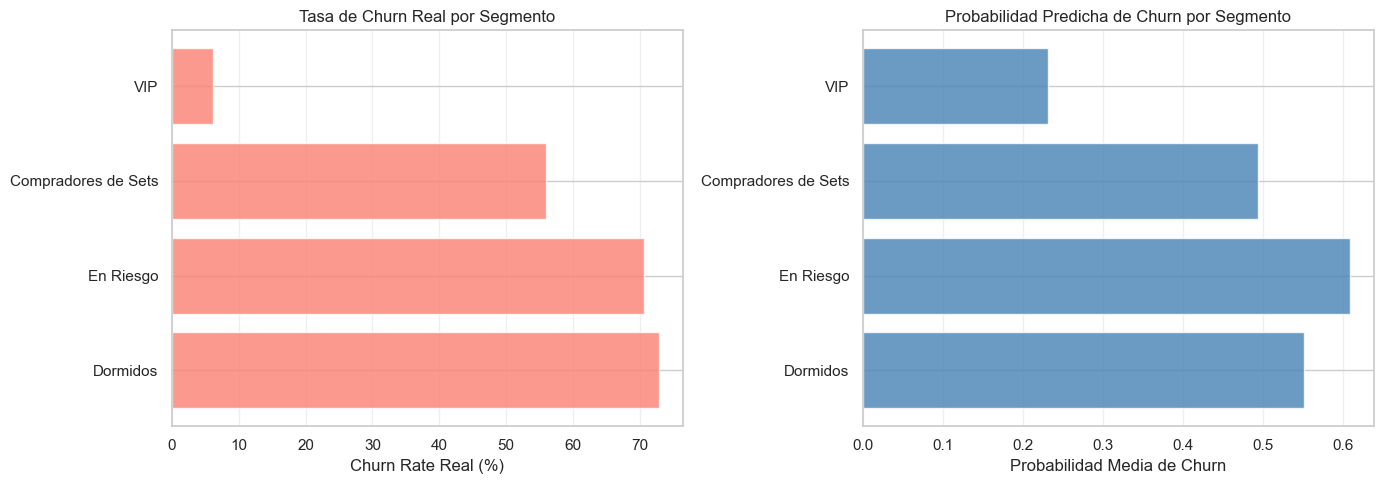

In [23]:
# Visualizacion: churn por segmento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn rate real por segmento
order = segment_churn["churn_real_pct"].sort_values(ascending=False).index
axes[0].barh(order, segment_churn.loc[order, "churn_real_pct"], color="salmon", alpha=0.8)
axes[0].set_xlabel("Churn Rate Real (%)")
axes[0].set_title("Tasa de Churn Real por Segmento")
axes[0].grid(True, alpha=0.3, axis="x")

# Probabilidad media de churn por segmento
axes[1].barh(order, segment_churn.loc[order, "churn_prob_mean"], color="steelblue", alpha=0.8)
axes[1].set_xlabel("Probabilidad Media de Churn")
axes[1].set_title("Probabilidad Predicha de Churn por Segmento")
axes[1].grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig(REPORT_PATH / "churn_by_segment.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Guardar resultados

In [24]:
# Guardar modelo
with open(MODEL_PATH / "churn_model.pkl", "wb") as f:
    pickle.dump({
        "model": best_model,
        "model_name": best_name,
        "scaler": scaler,
        "features": FEATURE_NAMES,
        "rf_best_params": rf_grid.best_params_,
        "gb_best_params": gb_grid.best_params_,
    }, f)

# Guardar predicciones
churn_output = df[["CustomerID", "Churn", "churn_prob", "churn_pred"] + FEATURE_NAMES].copy()
churn_output.to_parquet(OUTPUT_PATH / "churn_predictions.parquet", index=False)

print(f"Modelo guardado: {MODEL_PATH / 'churn_model.pkl'}")
print(f"Predicciones guardadas: {OUTPUT_PATH / 'churn_predictions.parquet'}")
print(f"Shape predicciones: {churn_output.shape}")

Modelo guardado: ../../data/06_models/churn_model.pkl
Predicciones guardadas: ../../data/07_model_output/churn_predictions.parquet
Shape predicciones: (3317, 17)


## Conclusion

**Modelo:** Prediccion de churn (clasificacion binaria) con split temporal.

**Definicion de churn:**
- Observacion: 2010-12-01 a 2011-08-31 (9 meses para features)
- Prediccion: 2011-09-01 a 2011-12-09 (3 meses para target)
- 3,317 clientes en scope, 41.2% churn rate (balance razonable, no requiere oversampling)

**Features (13 totales):**
- 4 RFM recalculados (Recency, Frequency, Monetary, Cancel_rate)
- 5 atributos de producto del enriquecimiento (color, material, sets)
- 4 adicionales (regularidad, meses activos, diversidad, ticket promedio)

**Modelos comparados:**
- Random Forest con GridSearchCV (6 combinaciones x 5 folds)
- Gradient Boosting con GridSearchCV (4 combinaciones x 5 folds)

**Resultados (test set):**
- Se selecciono el modelo con mejor F1 en cross-validation
- Metricas incluyen classification report completo, AUC-ROC y matrices de confusion

**Hallazgos clave:**
- Recency es el predictor mas fuerte de churn (como era esperado)
- Los features adicionales (months_active, n_products_unique) aportan poder predictivo
- Los features de producto del enriquecimiento complementan la informacion RFM
- El cruce con segmentos del clustering revela que segmentos son mas riesgosos

**Valor de negocio:**
- El modelo permite identificar clientes en riesgo de churn ANTES de que se vayan
- Combinado con la segmentacion, permite disenar estrategias de retencion diferenciadas
- Los segmentos "Dormidos" y "En Riesgo" (del clustering) probablemente concentran el mayor churn

**Proximos pasos:**
1. Analisis combinado detallado en notebook 09 (segmentos + churn + recomendaciones)
2. Prototipo Streamlit con prediccion interactiva
3. Propuesta de despliegue y monitoreo del modelo